# EDEN Shanghai and SST prediction visualization

This notebook loads the sample files saved by `EDEN/eval_scientific.py` and visualizes intermediate targets, EDEN predictions, and absolute errors for Shanghai and SST. The evaluator currently saves the first conditioning frame, intermediate targets, and predictions; it does not save the final conditioning frame.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    import torch
except ImportError:
    torch = None

try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    widgets = None

repo_root = Path.cwd().resolve()
if repo_root.name == "analysis":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

sample_paths = {
    "Shanghai": repo_root / "samples/EDEN_Data_shanghai_patch128_T8_Shanghai_T8.npy",
    "SST": repo_root / "samples/EDEN_Data_sst_patch128_T10_RESST_T10.npy",
}

for name, path in sample_paths.items():
    print(f"{name}: {path} {'OK' if path.exists() else 'MISSING'}")

Shanghai: /pscratch/sd/p/puren93/puren/Interp-DM/samples/EDEN_Data_shanghai_patch128_T8_Shanghai_T8.npy OK
SST: /pscratch/sd/p/puren93/puren/Interp-DM/samples/EDEN_Data_sst_patch128_T10_RESST_T10.npy OK


## Load saved EDEN samples

In [2]:
def to_numpy(x):
    """Convert tensors, lists, and arrays from EDEN sample dumps into numpy arrays."""
    if torch is not None and isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    if isinstance(x, np.ndarray):
        return x
    if isinstance(x, (list, tuple)):
        return np.stack([to_numpy(item) for item in x], axis=0)
    return np.asarray(x)


def load_eden_samples(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    data = np.load(path, allow_pickle=True).item()
    loaded = {
        "conditioning_start": to_numpy(data["conditioning_snapshots"]),
        "targets": to_numpy(data["targets"]),
        "predictions": to_numpy(data["predictions"]),
    }
    return loaded


def describe_samples(name, samples):
    print(f"\n{name}")
    for key, value in samples.items():
        print(f"  {key:18s} shape={value.shape} dtype={value.dtype} min={np.nanmin(value):.4g} max={np.nanmax(value):.4g}")


eden_samples = {}
for name, path in sample_paths.items():
    if path.exists():
        eden_samples[name] = load_eden_samples(path)
        describe_samples(name, eden_samples[name])

if not eden_samples:
    raise RuntimeError("No EDEN sample files were found. Run EDEN/eval_scientific.py with save_samples: true first.")


Shanghai
  conditioning_start shape=(64, 1, 128, 128) dtype=float32 min=0 max=0.6472
  targets            shape=(8, 64, 1, 128, 128) dtype=float32 min=0 max=0.6706
  predictions        shape=(8, 64, 1, 128, 128) dtype=float32 min=-3.146 max=0.6349

SST
  conditioning_start shape=(64, 1, 128, 128) dtype=float32 min=-3.847 max=2.727
  targets            shape=(10, 64, 1, 128, 128) dtype=float32 min=-4.426 max=3.107
  predictions        shape=(10, 64, 1, 128, 128) dtype=float32 min=-5.434 max=2.4


## Plot helpers

In [3]:
def get_shanghai_cmap():
    try:
        from datasets.data_shanghai import COLOR_MAP
        return LinearSegmentedColormap.from_list("shanghai_radar", np.asarray(COLOR_MAP) / 255.0)
    except Exception:
        return "turbo"


dataset_display = {
    "Shanghai": {"cmap": get_shanghai_cmap(), "scale": 90.0, "label": "pixel scale"},
    "SST": {"cmap": "turbo", "scale": 1.0, "label": "saved units"},
}


def frame_at(sequence, sample_idx, step_idx, channel=0):
    # Expected saved shape: [time, batch, channel, height, width].
    frame = sequence[step_idx, sample_idx]
    if frame.ndim == 3:
        frame = frame[channel]
    return np.asarray(frame)


def condition_frame(samples, sample_idx, channel=0):
    frame = samples["conditioning_start"][sample_idx]
    if frame.ndim == 3:
        frame = frame[channel]
    return np.asarray(frame)


def choose_steps(total_steps, max_cols=5):
    if total_steps <= max_cols:
        return list(range(total_steps))
    return sorted(set(np.linspace(0, total_steps - 1, max_cols, dtype=int).tolist()))


def plot_eden_sample(dataset_name, sample_idx=0, steps=None, channel=0, scale=None, save_path=None):
    samples = eden_samples[dataset_name]
    targets = samples["targets"]
    preds = samples["predictions"]
    total_steps = targets.shape[0]
    if steps is None:
        steps = choose_steps(total_steps)
    steps = [int(step) for step in steps if 0 <= int(step) < total_steps]
    if not steps:
        raise ValueError(f"No valid steps for total_steps={total_steps}")

    display_cfg = dataset_display.get(dataset_name, {"cmap": "viridis", "scale": 1.0, "label": "saved units"})
    if scale is None:
        scale = display_cfg["scale"]
    cmap = display_cfg["cmap"]

    target_frames = [frame_at(targets, sample_idx, step, channel) * scale for step in steps]
    pred_frames = [frame_at(preds, sample_idx, step, channel) * scale for step in steps]
    error_frames = [np.abs(pred - target) for pred, target in zip(pred_frames, target_frames)]
    cond = condition_frame(samples, sample_idx, channel) * scale

    field_values = np.concatenate([np.ravel(cond)] + [f.ravel() for f in target_frames + pred_frames])
    vmin, vmax = np.nanpercentile(field_values, [1, 99])
    err_vmax = np.nanpercentile(np.concatenate([f.ravel() for f in error_frames]), 99)

    ncols = len(steps) + 1
    fig, axes = plt.subplots(3, ncols, figsize=(3.1 * ncols, 8.0), constrained_layout=True)
    fig.suptitle(f"{dataset_name} EDEN sample {sample_idx}", fontsize=14)

    ax = axes[0, 0]
    im = ax.imshow(cond, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title("conditioning start")
    ax.set_ylabel("target")
    ax.set_xticks([])
    ax.set_yticks([])

    axes[1, 0].axis("off")
    axes[1, 0].set_ylabel("EDEN")
    axes[2, 0].axis("off")
    axes[2, 0].set_ylabel("abs error")

    for col, step in enumerate(steps, start=1):
        axes[0, col].imshow(target_frames[col - 1], cmap=cmap, vmin=vmin, vmax=vmax)
        axes[0, col].set_title(f"step {step + 1}/{total_steps}")
        axes[1, col].imshow(pred_frames[col - 1], cmap=cmap, vmin=vmin, vmax=vmax)
        axes[2, col].imshow(error_frames[col - 1], cmap="magma", vmin=0.0, vmax=err_vmax)
        for row in range(3):
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])

    fig.colorbar(im, ax=axes[:2, :], shrink=0.7, label=display_cfg["label"])
    err_im = axes[2, 1].images[0]
    fig.colorbar(err_im, ax=axes[2, :], shrink=0.7, label="absolute error")

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"saved {save_path}")
    return fig


def plot_error_curve(dataset_name, sample_idx=0, channel=0, scale=None):
    samples = eden_samples[dataset_name]
    targets = samples["targets"]
    preds = samples["predictions"]
    if scale is None:
        scale = dataset_display.get(dataset_name, {}).get("scale", 1.0)
    errors = []
    for step in range(targets.shape[0]):
        target = frame_at(targets, sample_idx, step, channel) * scale
        pred = frame_at(preds, sample_idx, step, channel) * scale
        rel = np.linalg.norm(pred - target) / max(np.linalg.norm(target), 1e-12)
        mae = np.mean(np.abs(pred - target))
        errors.append((step + 1, rel, mae))
    errors = np.asarray(errors)

    fig, ax1 = plt.subplots(figsize=(7, 3.2), constrained_layout=True)
    ax1.plot(errors[:, 0], errors[:, 1], marker="o", label="relative L2")
    ax1.set_xlabel("interpolation step")
    ax1.set_ylabel("relative L2")
    ax1.grid(alpha=0.25)
    ax2 = ax1.twinx()
    ax2.plot(errors[:, 0], errors[:, 2], marker="s", color="tab:orange", label="MAE")
    ax2.set_ylabel("MAE")
    ax1.set_title(f"{dataset_name} sample {sample_idx} error by step")
    return fig, errors

## Static examples

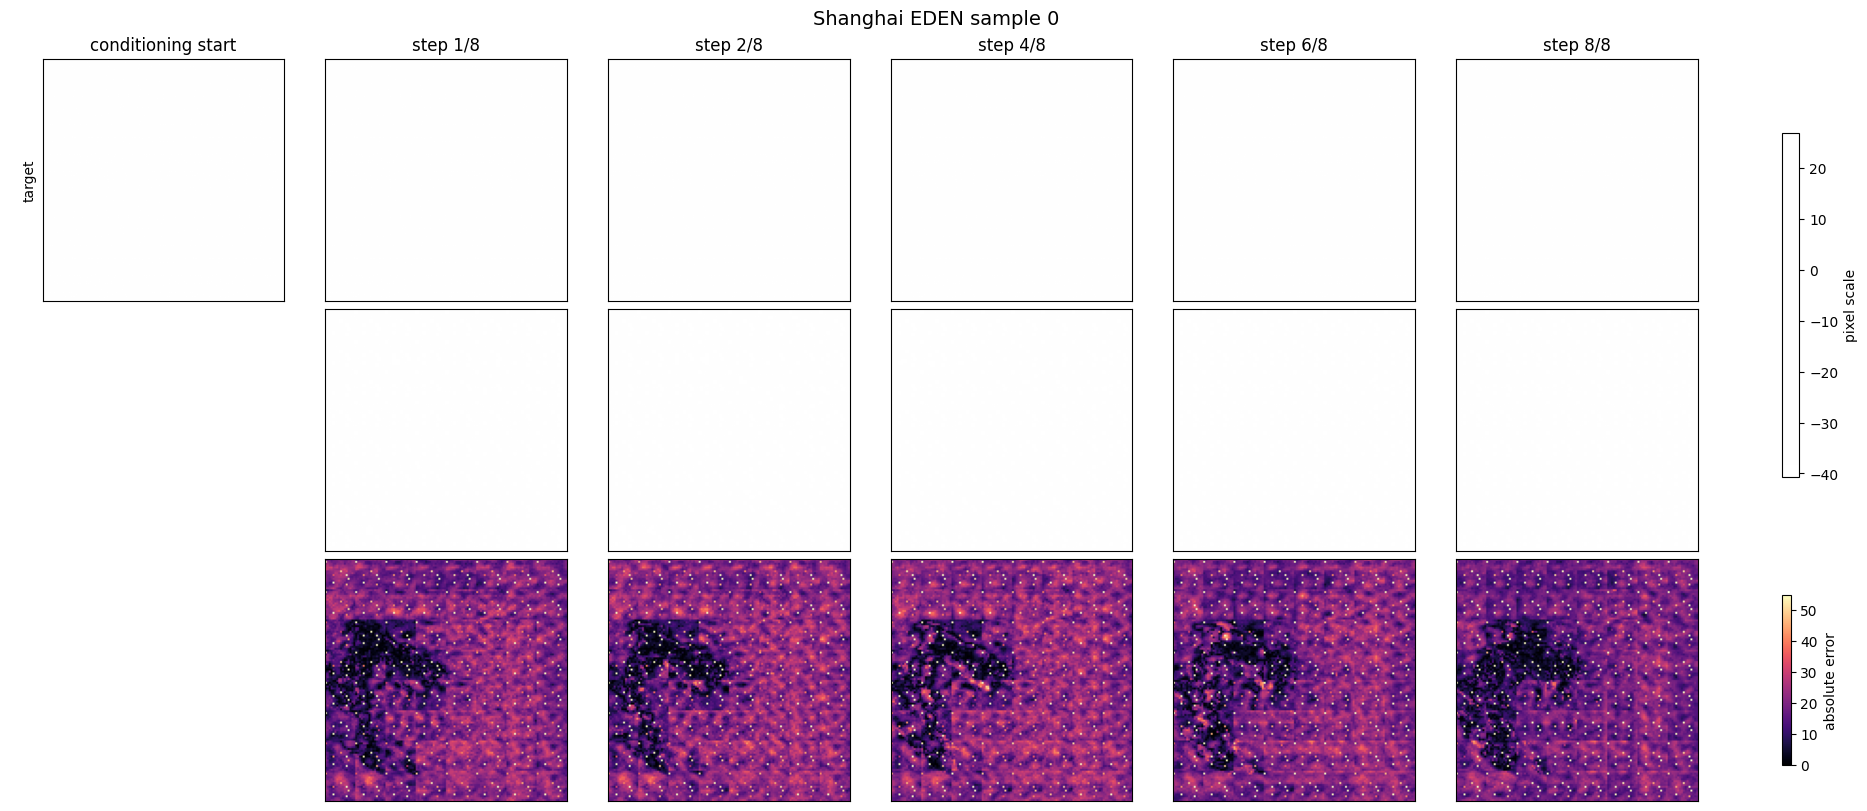

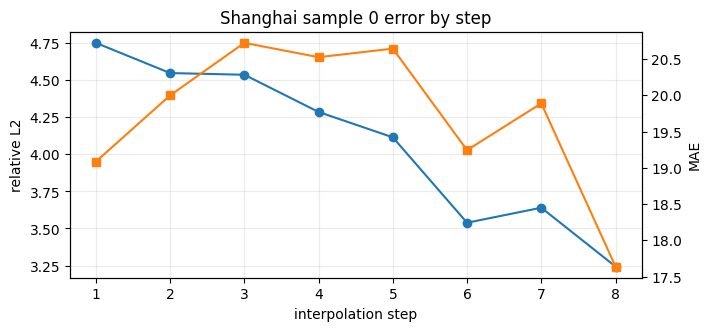

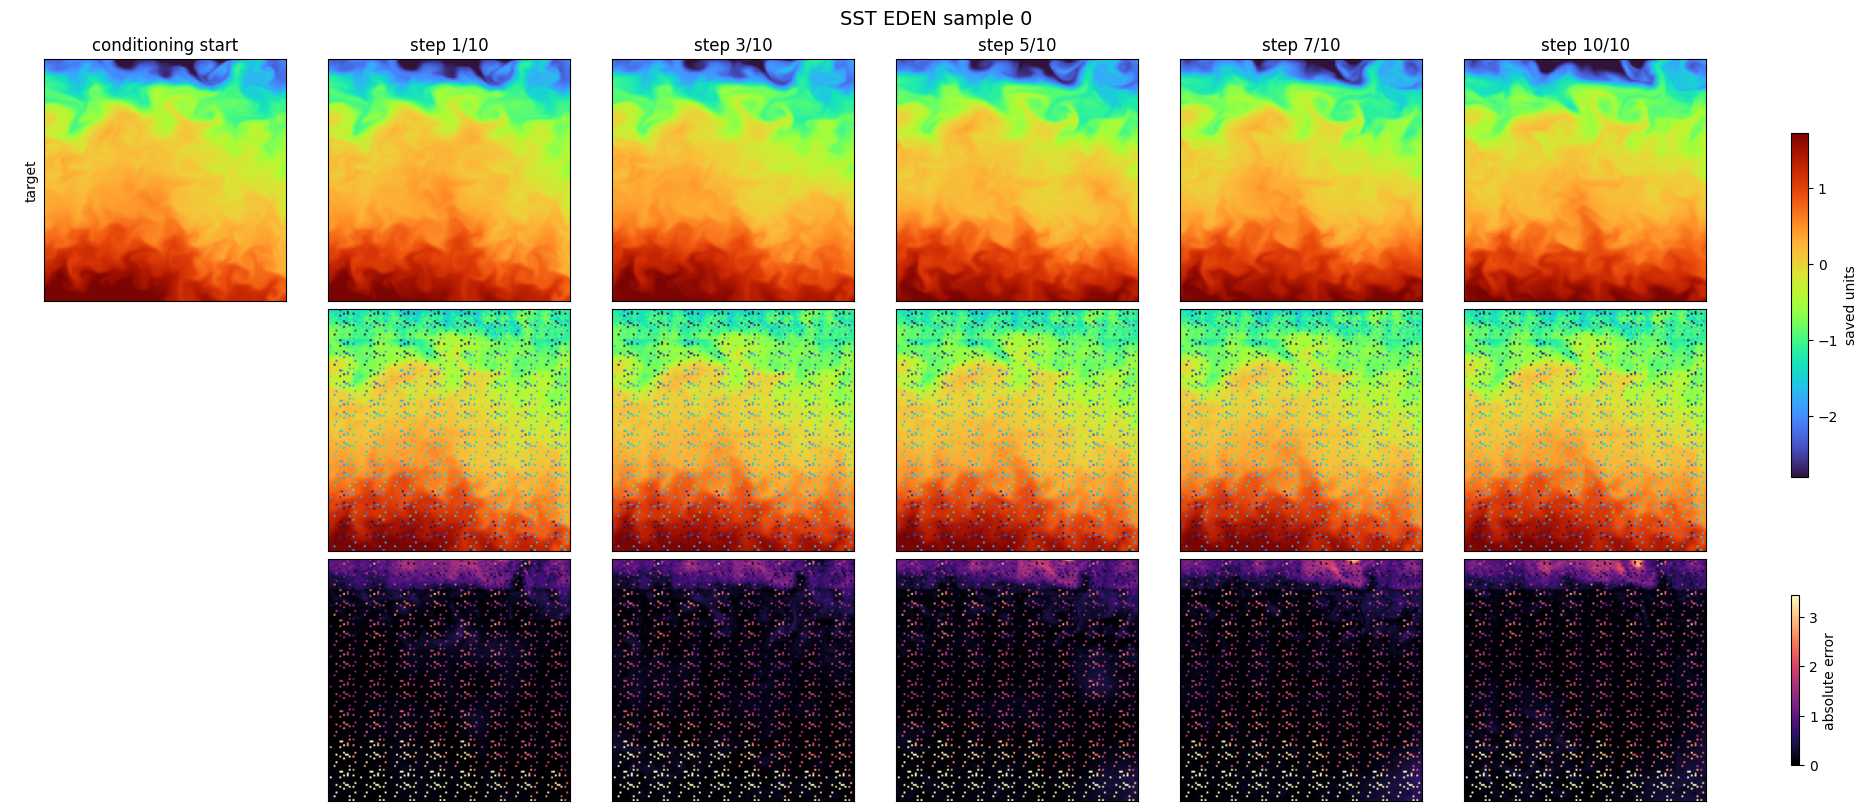

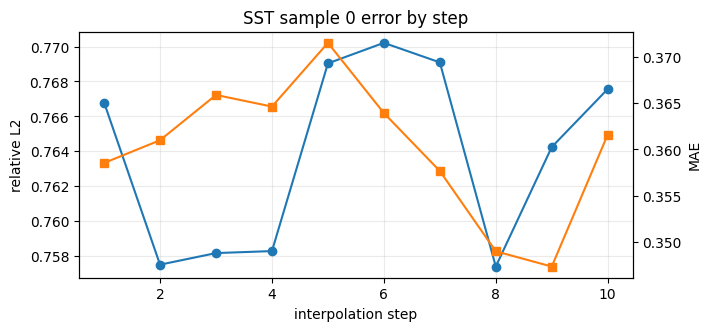

In [4]:
for dataset_name in eden_samples:
    max_sample = eden_samples[dataset_name]["targets"].shape[1] - 1
    sample_idx = min(0, max_sample)
    plot_eden_sample(dataset_name, sample_idx=sample_idx)
    plot_error_curve(dataset_name, sample_idx=sample_idx)
    plt.show()

## Interactive browser

In [5]:
if widgets is None:
    print("ipywidgets is not installed in this kernel. Use plot_eden_sample(...) and plot_error_curve(...) directly.")
else:
    dataset_widget = widgets.Dropdown(options=list(eden_samples.keys()), description="dataset")
    sample_widget = widgets.IntSlider(value=0, min=0, max=0, step=1, description="sample")
    max_cols_widget = widgets.IntSlider(value=5, min=1, max=10, step=1, description="columns")

    def sync_sample_range(*args):
        max_sample = eden_samples[dataset_widget.value]["targets"].shape[1] - 1
        sample_widget.max = max_sample
        sample_widget.value = min(sample_widget.value, max_sample)

    dataset_widget.observe(sync_sample_range, names="value")
    sync_sample_range()

    def browse(dataset_name, sample_idx, max_cols):
        total_steps = eden_samples[dataset_name]["targets"].shape[0]
        steps = choose_steps(total_steps, max_cols=max_cols)
        plot_eden_sample(dataset_name, sample_idx=sample_idx, steps=steps)
        plot_error_curve(dataset_name, sample_idx=sample_idx)
        plt.show()

    ui = widgets.VBox([dataset_widget, sample_widget, max_cols_widget])
    out = widgets.interactive_output(
        browse,
        {"dataset_name": dataset_widget, "sample_idx": sample_widget, "max_cols": max_cols_widget},
    )
    display(ui, out)

ipywidgets is not installed in this kernel. Use plot_eden_sample(...) and plot_error_curve(...) directly.


## Save selected figures

In [6]:
output_dir = repo_root / "analysis/eden_prediction_figures"

# Edit these indices as needed.
selected_samples = {
    "Shanghai": [0, 1, 2],
    "SST": [0, 1, 2],
}

for dataset_name, indices in selected_samples.items():
    if dataset_name not in eden_samples:
        continue
    max_sample = eden_samples[dataset_name]["targets"].shape[1] - 1
    for sample_idx in indices:
        if sample_idx > max_sample:
            continue
        save_path = output_dir / f"eden_{dataset_name.lower()}_sample_{sample_idx:04d}.png"
        fig = plot_eden_sample(dataset_name, sample_idx=sample_idx, save_path=save_path)
        plt.close(fig)

saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/eden_prediction_figures/eden_shanghai_sample_0000.png
saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/eden_prediction_figures/eden_shanghai_sample_0001.png
saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/eden_prediction_figures/eden_shanghai_sample_0002.png
saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/eden_prediction_figures/eden_sst_sample_0000.png
saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/eden_prediction_figures/eden_sst_sample_0001.png
saved /pscratch/sd/p/puren93/puren/Interp-DM/analysis/eden_prediction_figures/eden_sst_sample_0002.png


## SST raw target and conditioning frames

Use this block to check whether the original SST eval patch already contains the speckle or boundary artifacts. The saved EDEN sample file only stores `conditioning_start`, not `conditioning_end`, so this reloads the deterministic SST eval subset used by `EDEN/eval_sst.py`.

66222 indices found in /global/cfs/projectdirs/m4633/puren/interp_dm/sea_temp/sea_temperaturetest_10_10.pkl


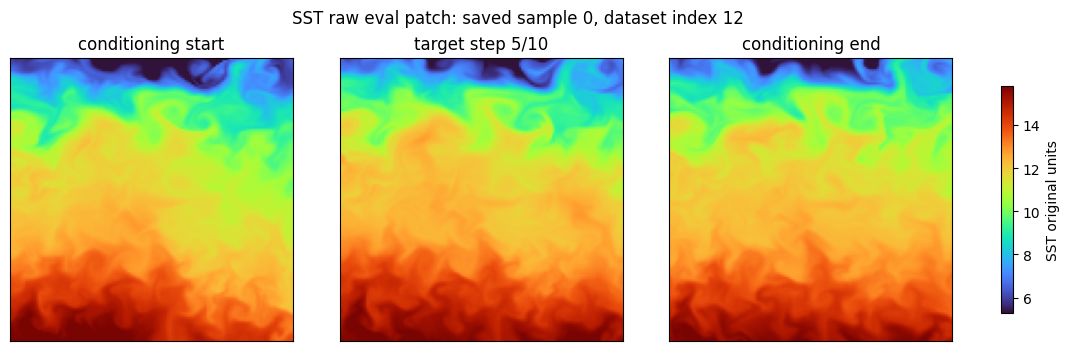

In [8]:
import os
import yaml


sst_config_path = repo_root / "EDEN/configs/eval_eden_sst.yaml"


def ensure_eden_import_path():
    eden_dir = repo_root / "EDEN"
    if str(eden_dir) not in sys.path:
        sys.path.insert(0, str(eden_dir))


def load_sst_eval_config(config_path=sst_config_path):
    with open(config_path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f) or {}


def sst_subset_indices(dataset_len, max_eval_samples=None):
    if max_eval_samples is None:
        max_eval_samples = int(os.getenv("SST_EVAL_MAX_SAMPLES", "2048"))
    if max_eval_samples > 0 and dataset_len > max_eval_samples:
        rng = np.random.default_rng(0)
        return np.sort(rng.choice(dataset_len, size=max_eval_samples, replace=False))
    return np.arange(dataset_len)


def load_sst_eval_dataset(config_path=sst_config_path):
    ensure_eden_import_path()
    from src.datasets import load_dataset

    cfg = load_sst_eval_config(config_path)
    dataset = load_dataset(
        "sst_eval",
        data_path=cfg["data_path"],
        total_interp_steps=cfg["total_interp_steps"],
    )
    subset = sst_subset_indices(len(dataset))
    return dataset, subset, cfg


def tensor_frame_to_numpy(x):
    x = to_numpy(x)
    if x.ndim == 3:
        x = x[0]
    return np.asarray(x)


def get_sst_eval_triplet(sample_idx=0, step_idx=None):
    dataset, subset, cfg = load_sst_eval_dataset()
    original_idx = int(subset[int(sample_idx)])
    inputs, targets, cond_params = dataset[original_idx]
    total_steps = int(cond_params[0].item())
    if step_idx is None:
        step_idx = total_steps // 2
    step_idx = int(np.clip(step_idx, 0, total_steps - 1))
    norm_stats = to_numpy(cond_params[2])
    return {
        "sample_idx": int(sample_idx),
        "original_idx": original_idx,
        "step_idx": step_idx,
        "total_steps": total_steps,
        "condition_start": inputs[0],
        "condition_end": inputs[1],
        "target": targets[step_idx],
        "norm_stats": norm_stats,
        "config": cfg,
    }


def inverse_sst_zscore(frame, norm_stats, time_index):
    mean, std = norm_stats[int(time_index)]
    return frame * std + mean


def plot_sst_raw_triplet(sample_idx=0, step_idx=None, original_units=True):
    item = get_sst_eval_triplet(sample_idx=sample_idx, step_idx=step_idx)
    total_steps = item["total_steps"]
    target_time_index = item["step_idx"] + 1
    frames = [
        tensor_frame_to_numpy(item["condition_start"]),
        tensor_frame_to_numpy(item["target"]),
        tensor_frame_to_numpy(item["condition_end"]),
    ]
    titles = [
        "conditioning start",
        f"target step {item['step_idx'] + 1}/{total_steps}",
        "conditioning end",
    ]
    if original_units:
        frames = [
            inverse_sst_zscore(frames[0], item["norm_stats"], 0),
            inverse_sst_zscore(frames[1], item["norm_stats"], target_time_index),
            inverse_sst_zscore(frames[2], item["norm_stats"], total_steps + 1),
        ]
        label = "SST original units"
    else:
        label = "z-scored SST"

    vmin, vmax = np.nanpercentile(np.concatenate([x.ravel() for x in frames]), [1, 99])
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), constrained_layout=True)
    for ax, frame, title in zip(axes, frames, titles):
        im = ax.imshow(frame, cmap="turbo", vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.colorbar(im, ax=axes, shrink=0.8, label=label)
    fig.suptitle(f"SST raw eval patch: saved sample {item['sample_idx']}, dataset index {item['original_idx']}")
    return fig, item


fig, sst_item = plot_sst_raw_triplet(sample_idx=0, step_idx=4, original_units=True)
plt.show()

## SST VAE reconstruction diagnostic

This bypasses DiT sampling and tests only `EDEN_VAE`: true `conditioning_start`, true `conditioning_end`, and a true target frame go through VAE encode/decode. If this reconstruction already has speckles or a 16-pixel grid, the artifact is mainly from the VAE/reconstruction path rather than the DiT sampler.

66222 indices found in /global/cfs/projectdirs/m4633/puren/interp_dm/sea_temp/sea_temperaturetest_10_10.pkl


/pscratch/sd/p/puren93/conda_env/eden/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


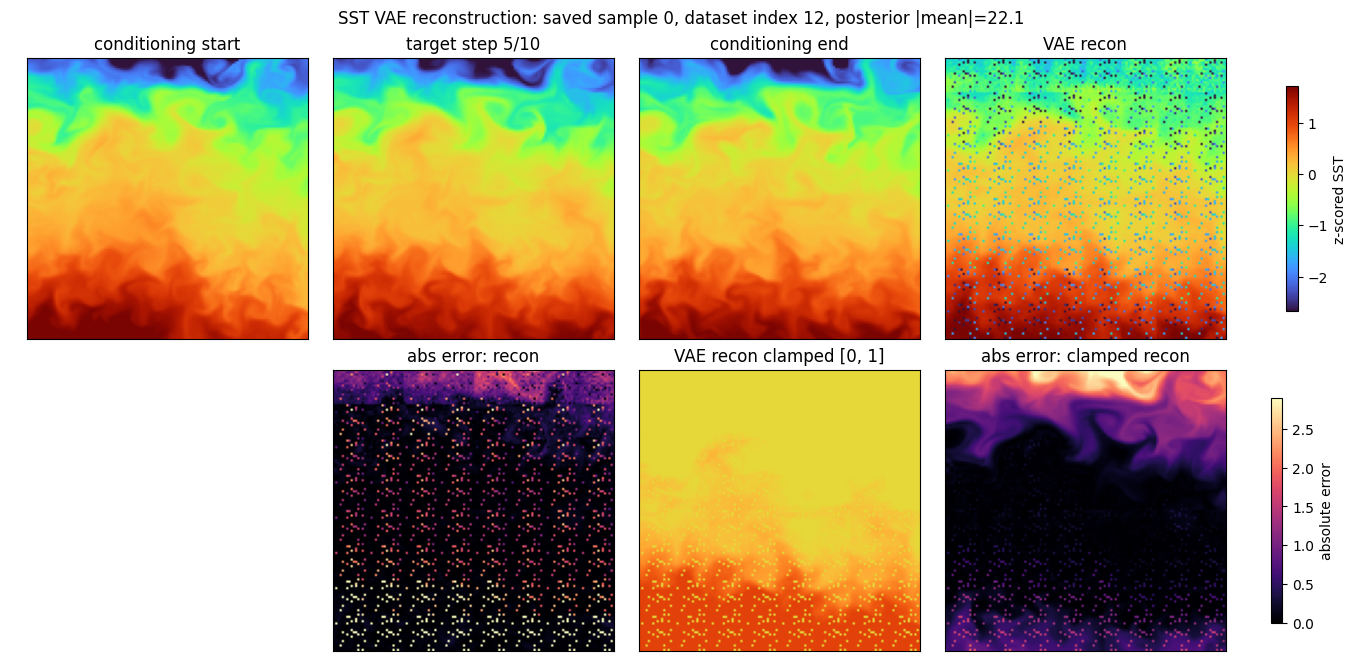

In [9]:
def load_eden_vae_for_sst(config_path=sst_config_path, checkpoint_path=None, device=None):
    if torch is None:
        raise ImportError("torch is required for the VAE reconstruction diagnostic")
    ensure_eden_import_path()
    from src.models import load_model

    cfg = load_sst_eval_config(config_path)
    if checkpoint_path is None:
        checkpoint_path = cfg["vae_checkpoint_path"]
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    vae = load_model("EDEN_VAE", **cfg["vae_args"]).to(device)
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    state_dict = checkpoint["eden_vae"] if "eden_vae" in checkpoint else checkpoint
    missing, unexpected = vae.load_state_dict(state_dict, strict=False)
    if missing or unexpected:
        print("Loaded VAE with non-strict state dict")
        print("missing:", missing)
        print("unexpected:", unexpected)
    vae.eval()
    return vae, cfg, torch.device(device)


def vae_reconstruct_sst_sample(sample_idx=0, step_idx=None, vae=None, device=None):
    if torch is None:
        raise ImportError("torch is required for the VAE reconstruction diagnostic")
    ensure_eden_import_path()
    from src.utils import InputPadder

    item = get_sst_eval_triplet(sample_idx=sample_idx, step_idx=step_idx)
    if vae is None:
        vae, _, device = load_eden_vae_for_sst(device=device)
    elif device is None:
        device = next(vae.parameters()).device

    start = item["condition_start"].unsqueeze(0).to(device)
    end = item["condition_end"].unsqueeze(0).to(device)
    target = item["target"].unsqueeze(0).to(device)
    frames = torch.cat((start, end, target), dim=0)
    padder = InputPadder([frames.shape[-2], frames.shape[-1]])

    with torch.no_grad():
        recon, posterior = vae(padder.pad(frames))
        recon = padder.unpad(recon)

    item["target_np"] = tensor_frame_to_numpy(item["target"])
    item["recon_np"] = recon[0, 0].detach().cpu().numpy()
    item["recon_clamped_np"] = np.clip(item["recon_np"], 0.0, 1.0)
    item["posterior_mean_abs"] = float(posterior.mean.detach().abs().mean().cpu())
    return item


def plot_sst_vae_reconstruction(sample_idx=0, step_idx=None, original_units=False, vae=None, device=None):
    item = vae_reconstruct_sst_sample(sample_idx=sample_idx, step_idx=step_idx, vae=vae, device=device)
    total_steps = item["total_steps"]
    target_time_index = item["step_idx"] + 1

    start = tensor_frame_to_numpy(item["condition_start"])
    target = item["target_np"]
    end = tensor_frame_to_numpy(item["condition_end"])
    recon = item["recon_np"]
    recon_clamped = item["recon_clamped_np"]

    if original_units:
        start = inverse_sst_zscore(start, item["norm_stats"], 0)
        target = inverse_sst_zscore(target, item["norm_stats"], target_time_index)
        end = inverse_sst_zscore(end, item["norm_stats"], total_steps + 1)
        recon = inverse_sst_zscore(recon, item["norm_stats"], target_time_index)
        recon_clamped = inverse_sst_zscore(recon_clamped, item["norm_stats"], target_time_index)
        label = "SST original units"
    else:
        label = "z-scored SST"

    err = np.abs(recon - target)
    err_clamped = np.abs(recon_clamped - target)
    field_values = np.concatenate([x.ravel() for x in [start, target, end, recon, recon_clamped]])
    vmin, vmax = np.nanpercentile(field_values, [1, 99])
    err_vmax = np.nanpercentile(np.concatenate([err.ravel(), err_clamped.ravel()]), 99)

    fig, axes = plt.subplots(2, 4, figsize=(13.5, 6.5), constrained_layout=True)
    field_panels = [
        (start, "conditioning start"),
        (target, f"target step {item['step_idx'] + 1}/{total_steps}"),
        (end, "conditioning end"),
        (recon, "VAE recon"),
    ]
    for ax, (frame, title) in zip(axes[0], field_panels):
        im = ax.imshow(frame, cmap="turbo", vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

    error_panels = [
        (err, "abs error: recon"),
        (recon_clamped, "VAE recon clamped [0, 1]"),
        (err_clamped, "abs error: clamped recon"),
    ]
    axes[1, 0].axis("off")
    err_im = None
    for ax, (frame, title) in zip(axes[1, 1:], error_panels):
        cmap = "magma" if "error" in title else "turbo"
        if "error" in title:
            err_im = ax.imshow(frame, cmap=cmap, vmin=0.0, vmax=err_vmax)
        else:
            ax.imshow(frame, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

    fig.colorbar(im, ax=axes[0, :], shrink=0.8, label=label)
    if err_im is not None:
        fig.colorbar(err_im, ax=axes[1, 1:], shrink=0.8, label="absolute error")
    fig.suptitle(
        f"SST VAE reconstruction: saved sample {item['sample_idx']}, "
        f"dataset index {item['original_idx']}, posterior |mean|={item['posterior_mean_abs']:.3g}"
    )
    return fig, item


# Run once and reuse the VAE object for additional samples to avoid reloading the checkpoint.
sst_vae, _, sst_vae_device = load_eden_vae_for_sst()
fig, vae_item = plot_sst_vae_reconstruction(
    sample_idx=0,
    step_idx=4,
    original_units=False,
    vae=sst_vae,
    device=sst_vae_device,
)
plt.show()